# Tutorial: Logical Randomized Benchmarking under Correlated Noise

This notebook builds on `tutorial.ipynb` and demonstrates **single-qubit logical
randomized benchmarking (RB)** on top of the temporally-correlated ("long-time
pairwise" / "long-time streaky") noise models implemented in `src/noisemodel`.

## Protocol

Starting from the code's prepared logical state, we apply a random sequence of
`L` logical Pauli gates drawn from `{I, X, Y, Z}`, each followed by
`rounds_between_gates` rounds of syndrome extraction:

```
|0>_L --[m rounds]--[gate 1]--[m rounds]--[gate 2]--...--[gate L]--[m rounds]--[recovery]--[measure]
```

* **Gate set.** The logical Pauli gates `{I, X, Y, Z}` are implemented as
  *transversal* physical `X`/`Z` operators on exactly the data qubits that
  support the code's logical `X`/`Z` operator. Logical `X`/`Z` always commute
  with every stabilizer of a CSS code, so inserting them mid-circuit changes
  *only* the expected final value of the logical observable -- never the
  detector structure. This makes them safe to insert into the existing
  circuits with no risk of silently breaking the decoder.
* **Recovery gate.** Mod global phase, `{I, X, Y, Z}` is the Klein four-group:
  every non-identity element is its own inverse, and composition is just XOR
  of an `(has_X, has_Z)` pair. We track this 2-bit "frame" exactly as the
  random gates are chosen, and close the sequence with one extra gate equal
  to the accumulated frame -- which exactly cancels it. In the absence of
  physical errors the circuit therefore returns to its original logical
  state, and the existing decode-vs-actual-observable comparison used
  everywhere else in this repository works unchanged.
* **Noise resets at each gate.** Each `m`-round block between two gates is
  sampled as an *independent* draw from the chosen correlated noise model
  (using that model's own `rounds=m` pair/streak statistics). This means a
  long-time streak or a pairwise correlation never spans a gate boundary --
  a deliberate simplification that lets us reuse the existing, validated
  per-round error-sampling code in `src/noisemodel` completely unmodified.

## What's new here

All of the new orchestration logic lives in `src/rb/rb.py` (read it for full
detail/derivations). It does **not** modify any existing file in `src/` --
it only calls into the public/semi-public methods each noise model class
already exposes (`sample_errors`, `sample_control_errors`,
`calc_marginals_per_round`, `split_circuit`, `get_targets`), driving a single
persistent `stim.FlipSimulator` across multiple gate-separated blocks.

## Supported codes and noise classes

| Noise class | What it targets | Rotated surface code | Repetition code |
|---|---|---|---|
| Class 0 (`noisy_qubits='data'`) | data qubits | Yes | Yes |
| Class 1 simple (`noisy_qubits='syndrome'`) | syndrome qubits, errors at round start | Yes | Yes |
| Class 1 precise (`LongTimePairMPoly` etc.) | syndrome qubits, errors right before MR | Yes | No¹ |
| Class 2 (`LongTimePairCPoly` etc.) | two-qubit CX gates | Yes | No¹ |
| All / mixed (`LongTimePairAPoly` etc.) | data + syndrome + CX combined | Yes | No¹ |
| All-qubit simple (`noisy_qubits='all'`) | data ∪ syndrome, errors at round start | Yes | Yes |

¹ The precise Class 1, Class 2, and "All" model classes hard-code the rotated
surface code's specific round geometry (4 CX layers per round, and an `H`
instruction used to tell X- and Z-type syndrome qubits apart). The repetition
code's round structure doesn't match this, so those classes are out of scope
for it -- use the simple `noisy_qubits=...` parameterization on the base
`LongTimePair*`/`LongTimeStreak*` classes instead, which only assumes a
generic per-round error injection point and works for any code.

**A repetition-code caveat worth internalizing up front:** the repetition
code used here only protects against bit-flip (`X`) errors. Its logical `Z`
operator has a *weight-1* representative -- a single `Z` error on any one
data qubit is, mod stabilizers, already a complete logical `Z` error, with
no distance protection at all. Logical `X`, by contrast, requires the full
transversal product over all `d` data qubits and *is* distance-protected.
This asymmetry will show up clearly in the repetition-code results below.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import stim
import pymatching

from src.noisemodel import (
    LongTimePairPoly, LongTimePairExp, LongTimeStreakPoly, LongTimeStreakExp,
    LongTimePairMPoly, LongTimePairMExp, LongTimeStreakMPoly, LongTimeStreakMExp,
    LongTimePairCPoly, LongTimePairCExp, LongTimeStreakCPoly, LongTimeStreakCExp,
    LongTimePairAPoly, LongTimePairAExp, LongTimeStreakAPoly, LongTimeStreakAExp,
)
from src.rb import (
    get_logical_pauli_support, gen_random_pauli_sequence, run_rb_batch,
    build_marginalised_rb_circuit, supported_codes_for_model,
)

rng = np.random.default_rng(0)
print("Imports successful.")


Imports successful.


## 1. Configure the experiment

Pick the QEC code, the noise model, and the RB sequence parameters here. This
is the main "knobs" cell -- everything below reruns cleanly if you change
these and re-execute downstream cells.


In [2]:
# --- QEC code -----------------------------------------------------------
code = "surface_code"          # "surface_code" or "repetition_code"
distance = 5

# --- Noise model ----------------------------------------------------------
# Pick ONE of the constructors below (uncomment exactly one), or write your own.
# A, p, n follow the paper's poly_decay / exp_decay convention: A*p/r**n (poly)
# or A*p/n**r (exp), where r is the round separation.

p = 2e-3

# Class 0 -- data-qubit correlated noise, streaky:
model = LongTimeStreakPoly(A=1, p=p, n=2, noisy_qubits="data")

# Class 1 (simple, code-agnostic) -- syndrome-qubit correlated noise:
# model = LongTimeStreakPoly(A=1, p=p, n=2, noisy_qubits="syndrome")

# Class 1 (precise timing, surface code only):
# model = LongTimeStreakMPoly(A=1, p=p, n=2)

# Class 2 -- CX-correlated noise (surface code only):
# model = LongTimeStreakCPoly(A=1, p=p, n=2)

# All-qubit simple (code-agnostic):
# model = LongTimeStreakPoly(A=1, p=p, n=2, noisy_qubits="all")

# All classes mixed with precise timing (surface code only):
# model = LongTimeStreakAPoly(A=1, p=p, n=2)

# --- RB sequence parameters ------------------------------------------------
rounds_between_gates = 3        # QEC rounds between consecutive logical gates
sequence_lengths = [0, 2, 4, 6, 8, 10, 14]   # number of random gates L to sweep
num_sequences = 8               # independent random gate sequences per L
shots_per_sequence = 2000        # circuit shots per random sequence

assert code in supported_codes_for_model(model), (
    f"{type(model).__name__} does not support {code!r}; see the compatibility table above."
)
print(f"Using {type(model).__name__} on {code} (d={distance}), "
      f"{rounds_between_gates} rounds/gate, sequence lengths {sequence_lengths}")


Using LongTimeStreakPoly on surface_code (d=5), 3 rounds/gate, sequence lengths [0, 2, 4, 6, 8, 10, 14]


## 2. Inspect the logical Pauli support

This is exactly the set of physical data qubits that get a transversal `X` or
`Z` applied for each logical gate, automatically extracted from stim's own
generated circuits (not hand-derived lattice geometry) so it is guaranteed
consistent with the circuit's actual detector/observable definitions.


In [3]:
logical_support = get_logical_pauli_support(code, distance)
print("Logical X support (physical qubits):", logical_support["X"])
print("Logical Z support (physical qubits):", logical_support["Z"])


Logical X support (physical qubits): [1, 12, 23, 34, 45]
Logical Z support (physical qubits): [1, 3, 5, 7, 9]


## 3. Run a single RB sequence (sanity check)

Before sweeping, run one sequence and inspect what comes out: the random gate
sequence, the analytically-determined recovery gate, and the shapes of the
detection-event / observable-flip arrays.


In [4]:
demo_sequence = gen_random_pauli_sequence(6, rng=rng)
detection_events, observable_flips, recovery_gate = run_rb_batch(
    model, code, distance, rounds_between_gates, demo_sequence,
    batch_size=500, logical_support=logical_support,
)
print("Random gate sequence:", demo_sequence)
print("Recovery gate:        ", recovery_gate)
print("detection_events shape:", detection_events.shape)
print("observable_flips: {} / {} shots flipped".format(observable_flips.sum(), len(observable_flips)))


Random gate sequence: ['Z', 'Y', 'Y', 'X', 'X', 'I']
Recovery gate:         Z
detection_events shape: (500, 504)
observable_flips: 48 / 500 shots flipped


## 4. Sweep sequence length and decode

For each sequence length `L`, draw `num_sequences` independent random gate
sequences, simulate `shots_per_sequence` shots of each, decode with PyMatching
against a detector error model built from the same noise model's own marginal
statistics (`build_marginalised_rb_circuit`), and average the logical error
rate across all sequences of that length -- the standard randomized
benchmarking averaging procedure.


In [5]:
def run_rb_sweep(model, code, distance, rounds_between_gates, sequence_lengths,
                  num_sequences, shots_per_sequence, logical_support, rng):
    mean_error_rates = []
    std_error_rates = []

    for L in sequence_lengths:
        dem = build_marginalised_rb_circuit(
            model, code, distance, rounds_between_gates, num_gates=L
        ).detector_error_model()
        matcher = pymatching.Matching.from_detector_error_model(dem)

        rates = []
        for _ in range(num_sequences):
            seq = gen_random_pauli_sequence(L, rng=rng)
            det, obs, _ = run_rb_batch(
                model, code, distance, rounds_between_gates, seq,
                batch_size=shots_per_sequence, logical_support=logical_support,
            )
            pred = matcher.decode_batch(det).flatten()
            n_errors = np.sum(pred != obs)
            rates.append(n_errors / shots_per_sequence)

        mean_error_rates.append(np.mean(rates))
        std_error_rates.append(np.std(rates) / np.sqrt(num_sequences))
        print(f"L={L:3d}: logical error rate = {mean_error_rates[-1]:.4f} "
              f"+/- {std_error_rates[-1]:.4f}")

    return np.array(mean_error_rates), np.array(std_error_rates)


error_rates, error_rates_sem = run_rb_sweep(
    model, code, distance, rounds_between_gates, sequence_lengths,
    num_sequences, shots_per_sequence, logical_support, rng,
)


L=  0: logical error rate = 0.0000 +/- 0.0000
L=  2: logical error rate = 0.0000 +/- 0.0000
L=  4: logical error rate = 0.0000 +/- 0.0000
L=  6: logical error rate = 0.0001 +/- 0.0001
L=  8: logical error rate = 0.0003 +/- 0.0001
L= 10: logical error rate = 0.0003 +/- 0.0002
L= 14: logical error rate = 0.0003 +/- 0.0001


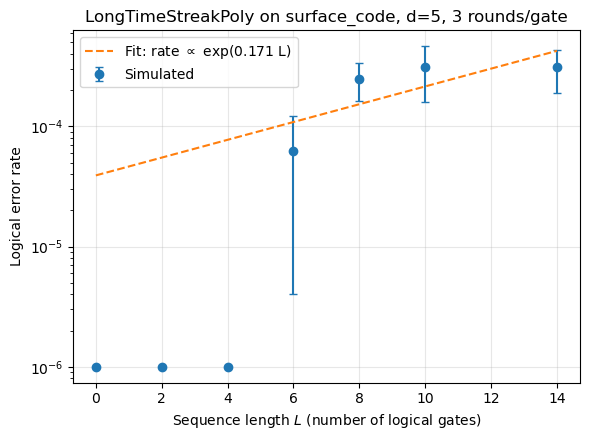

In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))

x = np.array(sequence_lengths)
y = np.clip(error_rates, 1e-6, None)
ax.errorbar(x, y, yerr=error_rates_sem, fmt='o', capsize=3, label='Simulated')

# Simple exponential fit on the log scale (same convention as tutorial.ipynb's
# Class 0 / Class 1 / pairwise-correlated panels): log(error rate) linear in L.
mask = error_rates > 0
if mask.sum() >= 2:
    coeffs = np.polyfit(x[mask], np.log(y[mask]), 1)
    x_fit = np.linspace(0, max(x), 100)
    ax.plot(x_fit, np.exp(np.polyval(coeffs, x_fit)), '--',
            label=f'Fit: rate $\\propto$ exp({coeffs[0]:.3f} L)')

ax.set_yscale('log')
ax.set_xlabel('Sequence length $L$ (number of logical gates)')
ax.set_ylabel('Logical error rate')
ax.set_title(f'{type(model).__name__} on {code}, d={distance}, '
             f'{rounds_between_gates} rounds/gate')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 5. Does breaking the noise into gate-separated blocks matter?

Because each `m`-round block is resampled independently of the others, the
RB circuit is somewhat different from a plain, uninterrupted memory
experiment of the same total round count: any long-time correlation
(particularly **streaks**) gets truncated at every gate boundary.

This cell directly compares, at matched total round count `m*(L+1)`:

* **Plain memory** -- a single uninterrupted block of `m*(L+1)` rounds
  (no gates, noise correlated/streaky across the whole run).
* **RB-style (gates = identity)** -- the exact same total round count, but
  split into `L+1` independently-sampled `m`-round blocks (gates are all
  `I`, isolating the effect of the noise reset itself from the effect of
  the random Pauli content).

For streaky noise this should show the gate-interrupted version doing
*better* (lower logical error rate) than the plain memory experiment, since
inserting gates -- even identity gates -- caps how long a single noise streak
can run. For pairwise/independent noise the effect should be much smaller,
since pairwise correlations are short-ranged enough that block-resetting
removes comparatively few same-block pairs.


In [7]:
def plain_memory_error_rate(model, code, distance, total_rounds, shots):
    template_circuit = stim.Circuit.generated(
        {"surface_code": "surface_code:rotated_memory_z",
         "repetition_code": "repetition_code:memory"}[code],
        rounds=total_rounds, distance=distance,
    )
    shots_done, errors = model.sample_logical_error_rate(
        template_circuit, repetitions=1, batch_size=shots, return_error_rate=False,
    )
    return errors / shots_done


def rb_identity_error_rate(model, code, distance, rounds_between_gates, L, shots, logical_support):
    dem = build_marginalised_rb_circuit(
        model, code, distance, rounds_between_gates, num_gates=L
    ).detector_error_model()
    matcher = pymatching.Matching.from_detector_error_model(dem)
    det, obs, _ = run_rb_batch(
        model, code, distance, rounds_between_gates, ["I"] * L,
        batch_size=shots, logical_support=logical_support,
    )
    pred = matcher.decode_batch(det).flatten()
    return np.sum(pred != obs) / shots


comparison_lengths = [2, 5, 8, 12, 16]
plain_rates = []
rb_identity_rates = []

for L in comparison_lengths:
    total_rounds = rounds_between_gates * (L + 1)
    plain_rates.append(
        plain_memory_error_rate(model, code, distance, total_rounds, shots_per_sequence)
    )
    rb_identity_rates.append(
        rb_identity_error_rate(model, code, distance, rounds_between_gates, L,
                                shots_per_sequence, logical_support)
    )
    print(f"total_rounds={total_rounds:3d}: plain memory = {plain_rates[-1]:.4f}, "
          f"gate-interrupted (noise reset) = {rb_identity_rates[-1]:.4f}")


total_rounds=  9: plain memory = 0.0000, gate-interrupted (noise reset) = 0.0000
total_rounds= 18: plain memory = 0.0000, gate-interrupted (noise reset) = 0.0000
total_rounds= 27: plain memory = 0.0015, gate-interrupted (noise reset) = 0.0000
total_rounds= 39: plain memory = 0.0015, gate-interrupted (noise reset) = 0.0000
total_rounds= 51: plain memory = 0.0025, gate-interrupted (noise reset) = 0.0010


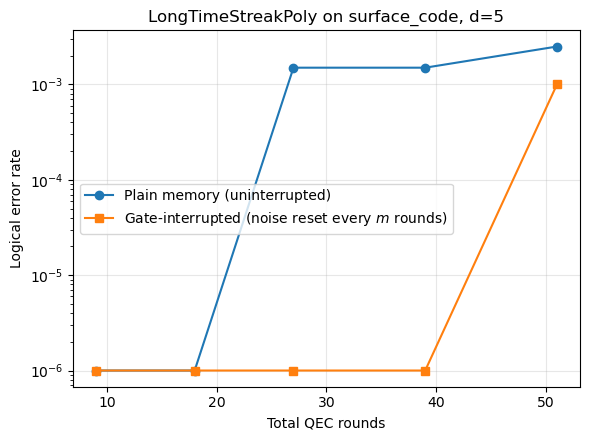

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.5))
total_rounds_list = [rounds_between_gates * (L + 1) for L in comparison_lengths]

ax.plot(total_rounds_list, np.clip(plain_rates, 1e-6, None), 'o-', label='Plain memory (uninterrupted)')
ax.plot(total_rounds_list, np.clip(rb_identity_rates, 1e-6, None), 's-', label='Gate-interrupted (noise reset every $m$ rounds)')
ax.set_yscale('log')
ax.set_xlabel('Total QEC rounds')
ax.set_ylabel('Logical error rate')
ax.set_title(f'{type(model).__name__} on {code}, d={distance}')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Repetition code: the X/Z asymmetry in practice

First, a quick sanity-check RB sweep on the repetition code with a generic
(depolarizing) Class 0 noise model, exactly like Section 4's surface-code
sweep -- logical error rate should grow with sequence length `L`.

**Then a sharper point.** It's tempting to think the X/Z asymmetry described
in the introduction (logical `Z`'s weight-1 representative vs logical `X`'s
weight-`d` representative) means a fixed *all-`Z`* gate sequence should decay
faster than a fixed *all-`X`* sequence. That turns out to be **not
observable this way**: in this protocol the logical gates themselves are
applied as ideal, noiseless Pauli-frame updates (`sim.do()` on a pure Pauli
circuit, no error channel attached). The per-block error statistics
(`sample_errors` / `calc_marginals_per_round`) depend only on
`rounds_between_gates`, never on which gate was chosen. So a fixed all-`X`
sequence and a fixed all-`Z` sequence are statistically indistinguishable --
both draw from the exact same per-round noise, just with a different
(noiselessly tracked) final frame. Confirming this is itself an informative,
if negative, result about where this design's noise can and can't enter.

The asymmetry **is** real, but it shows up in the *physical error type*, not
the gate choice. The repetition code's stabilizers are all `Z`-type, and its
logical readout is also a `Z`-basis measurement:

* A physical **`X` (bit-flip)** error anticommutes with the `Z` stabilizers
  -> it is detected, and (up to the code's distance) corrected.
* A physical **`Z` (phase-flip)** error commutes with *both* the `Z`
  stabilizers *and* the final `Z`-basis readout -> it produces **zero**
  detection events and has **zero** effect on the logical observable. It
  isn't merely "weakly protected" -- for this circuit it is completely
  invisible and inert.

The cell below instantiates the *same* noise model with `error_type='X'`
vs `error_type='Z'` (everything else identical) and runs an all-identity-gate
sweep (`gate_sequence=['I']*L`, so we're purely looking at how the per-round
noise itself behaves) to make this concrete.


In [9]:
rep_distance = 5
rep_model = LongTimeStreakPoly(A=1, p=2e-2, n=2, noisy_qubits="data")
rep_support = get_logical_pauli_support("repetition_code", rep_distance)
print("Repetition code logical support:", rep_support)

rep_sequence_lengths = [0, 2, 4, 6, 8]

print("--- Random Pauli sequences (X/Y/Z/I all equally likely) ---")
rep_error_rates, rep_error_rates_sem = run_rb_sweep(
    rep_model, "repetition_code", rep_distance, 3, rep_sequence_lengths,
    num_sequences=6, shots_per_sequence=2000, logical_support=rep_support, rng=rng,
)


Repetition code logical support: {'X': [0, 2, 4, 6, 8], 'Z': [8]}
--- Random Pauli sequences (X/Y/Z/I all equally likely) ---
L=  0: logical error rate = 0.0001 +/- 0.0001
L=  2: logical error rate = 0.0005 +/- 0.0002
L=  4: logical error rate = 0.0005 +/- 0.0002
L=  6: logical error rate = 0.0006 +/- 0.0001
L=  8: logical error rate = 0.0008 +/- 0.0003


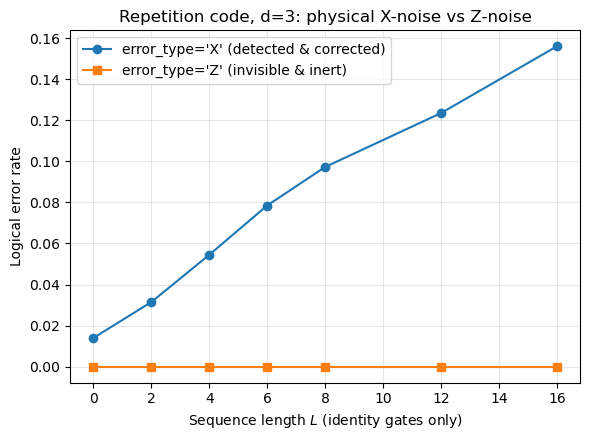

X-noise logical error rates: [0.014   0.0315  0.0545  0.0785  0.09725 0.1235  0.156  ]
Z-noise logical error rates: [0. 0. 0. 0. 0. 0. 0.]


In [10]:
def noise_type_sweep(model, code, distance, rounds_between_gates, sequence_lengths, shots, logical_support):
    """All-identity gate sequences: isolates the per-round noise's own effect,
    with no gate-content confound (see markdown above)."""
    rates = []
    for L in sequence_lengths:
        dem = build_marginalised_rb_circuit(
            model, code, distance, rounds_between_gates, num_gates=L
        ).detector_error_model()
        matcher = pymatching.Matching.from_detector_error_model(dem)
        det, obs, _ = run_rb_batch(
            model, code, distance, rounds_between_gates, ["I"] * L,
            batch_size=shots, logical_support=logical_support,
        )
        pred = matcher.decode_batch(det).flatten()
        rates.append(np.sum(pred != obs) / shots)
    return np.array(rates)


# Smaller distance / higher p than the rest of the notebook, purely so the
# decoder's residual (uncorrected) error rate for X noise is visibly nonzero
# and growing -- the contrast with Z noise (which is exactly zero regardless
# of distance, p, or round count) is the point, not realism of these values.
asym_distance = 3
asym_support = get_logical_pauli_support("repetition_code", asym_distance)
asym_sequence_lengths = [0, 2, 4, 6, 8, 12, 16]
asym_shots = 4000

model_x = LongTimeStreakPoly(A=1, p=5e-2, n=2, noisy_qubits="data", error_type="X")
model_z = LongTimeStreakPoly(A=1, p=5e-2, n=2, noisy_qubits="data", error_type="Z")

x_rates = noise_type_sweep(model_x, "repetition_code", asym_distance, 3, asym_sequence_lengths, asym_shots, asym_support)
z_rates = noise_type_sweep(model_z, "repetition_code", asym_distance, 3, asym_sequence_lengths, asym_shots, asym_support)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(asym_sequence_lengths, x_rates, 'o-', label="error_type='X' (detected & corrected)")
ax.plot(asym_sequence_lengths, z_rates, 's-', label="error_type='Z' (invisible & inert)")
ax.set_xlabel('Sequence length $L$ (identity gates only)')
ax.set_ylabel('Logical error rate')
ax.set_title(f'Repetition code, d={asym_distance}: physical X-noise vs Z-noise')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("X-noise logical error rates:", x_rates)
print("Z-noise logical error rates:", z_rates)


## Summary

* `src/rb/rb.py` implements logical Pauli-frame RB by driving a single
  `stim.FlipSimulator` across multiple gate-separated QEC-round blocks,
  reusing each noise model class's own per-round error-sampling primitives
  unmodified.
* Logical `X`/`Z` gates are extracted automatically from stim's own
  generated circuits (via the final-measurement / `OBSERVABLE_INCLUDE`
  structure), not hand-derived geometry, so they are guaranteed consistent
  with each circuit's detectors.
* The accumulated Pauli frame is tracked as a 2-bit `(has_X, has_Z)` value
  and cancelled exactly by a closing recovery gate, so a logical error is
  just "decoder prediction != actual observable flip", identical to a
  standard memory experiment.
* Class 0 (data) and the simple `noisy_qubits='syndrome'`/`'all'`
  parameterizations work for *any* code; the precise-timing Class 1, Class 2,
  and "All" mixed models are specific to the rotated surface code's round
  geometry.
* Breaking a noise history into independently-sampled blocks (the chosen
  "reset at each gate" design) measurably helps under streaky noise and
  has little effect under short-range pairwise/independent noise -- you can
  see this directly in Section 5.
* Because logical gates are applied as ideal, noiseless Pauli-frame updates,
  *which* gate you apply never changes the per-round noise statistics --
  only the physical *error type* the noise model injects does. Section 6
  shows this directly: for the repetition code, `error_type='X'` noise is
  detected and (partially) corrected, while `error_type='Z'` noise is
  completely invisible to both the stabilizers and the `Z`-basis logical
  readout, producing exactly zero detection events and zero logical errors.

Try changing the noise model in Section 1 to a pairwise-correlated variant
(`LongTimePairPoly`/`LongTimePairMPoly`/`LongTimePairCPoly`) and re-running
Section 5 to see the contrast with the streaky case.
